In [2]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

from sympy import *
from sympy.core import S

In [7]:

# E = (k/kb)**(-a1)*exp(-(kb/k))
# display(log(E).simplify())


alpha_1*(-log(omega) + log(omega_b)) - omega_b/omega

In [17]:
## ATTEMPTED GRAVEYARD:
# ((k/b)**(a1) + (k/b)**(a2))**(-1)
# (k/kb)**(-a1)*((k/kb) + S(1))**(a1 - a2)
#   -> Has partially usable solution for the equivalent spectrum for a1=1, a2=2

Text(0.5, 0, 'Angular frequency, $\\omega$')

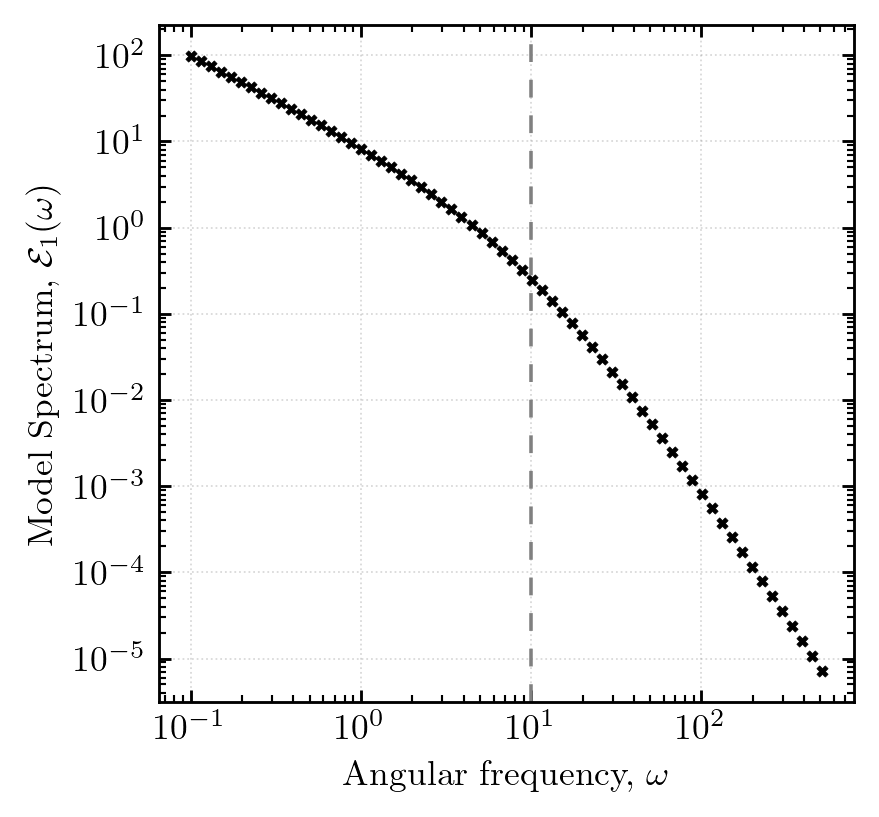

In [3]:
k = symbols('omega', positive=True, real=True)
t = symbols('tau', positive=True, real=True)

kb = symbols('omega_b', positive=True, real=True)

a1 = symbols('alpha_1', positive=True, real=True)
a2 = symbols('alpha_2', positive=True, real=True)

E = (k/kb)**(-a1)*((k/kb) + S(1))**(a1 - a2)

_k = np.exp(np.linspace(np.log(0.1), np.log(512), 64))
_a1 = 1.
_a2 = 3.
_kb = 10.

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for __k in _k:
    val = E.subs({k: __k, a1: _a1, a2: _a2, kb: _kb}).evalf()
    ax.scatter(__k, val, marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black')

ax.axvline(_kb, linestyle=(0,(5,5)), color='gray', linewidth=1.)

ax.loglog()

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'Model Spectrum, $\mathcal{E}_1(\omega)$')
ax.set_xlabel(r'Angular frequency, $\omega$')


In [25]:

E_new = E.subs({a1: S(1), a2: Rational(4,2), kb: S(1)})
display(E_new)

b = symbols('b', positive=True, real=True)

eq_E = (1/b) * S(1)/S(2) * t**2 * diff(2 * integrate((1-cos(k*t))*E_new, (k, 0, oo)), t)

display(eq_E.simplify())


1/(omega*(omega + 1))

tau**2*(-(Si(tau) - pi/2)*cos(tau) + sin(tau)*Ci(tau))/b

Limit(-tau**2*Integral(-omega*sin(omega*tau)/(omega**2 + omega), (omega, 0, oo))/b, tau, 0, dir='+')

In [20]:
valid = eq_E.simplify().args[0][0].subs({l: b/k})

eq = Eq(valid, E)
display(eq)
points = solve(eq, b)
for p in points:
    display(p)

H = symbols('H', positive=True, real=True)
display(p.subs({nu: S(1)+S(2)*H}))


Eq(2*sqrt(pi)*(A*b/omega)**alpha*gamma((3 - alpha)/2)/(2**alpha*b*gamma(alpha/2)), (A/omega)**alpha)

2**(alpha/(alpha - 1))*(gamma(alpha/2 + 1)/(sqrt(pi)*alpha))**(1/(alpha - 1))/gamma(3/2 - alpha/2)**(1/(alpha - 1))

2**((2*H + 1)/(2*H))*(gamma(H + 3/2)/(sqrt(pi)*(2*H + 1)))**(1/(2*H))/gamma(1 - H)**(1/(2*H))

In [21]:

bias = eq_E.simplify().args[0][0].subs({l: b/k})
bias = bias.subs({b: S(1)})
bias = bias / E

display(bias.simplify())
display(bias.subs({nu: S(1)+S(2)*H}))


2*sqrt(pi)*gamma(3/2 - alpha/2)/(2**alpha*gamma(alpha/2))

2*2**(-2*H - 1)*sqrt(pi)*gamma(1 - H)/gamma(H + 1/2)

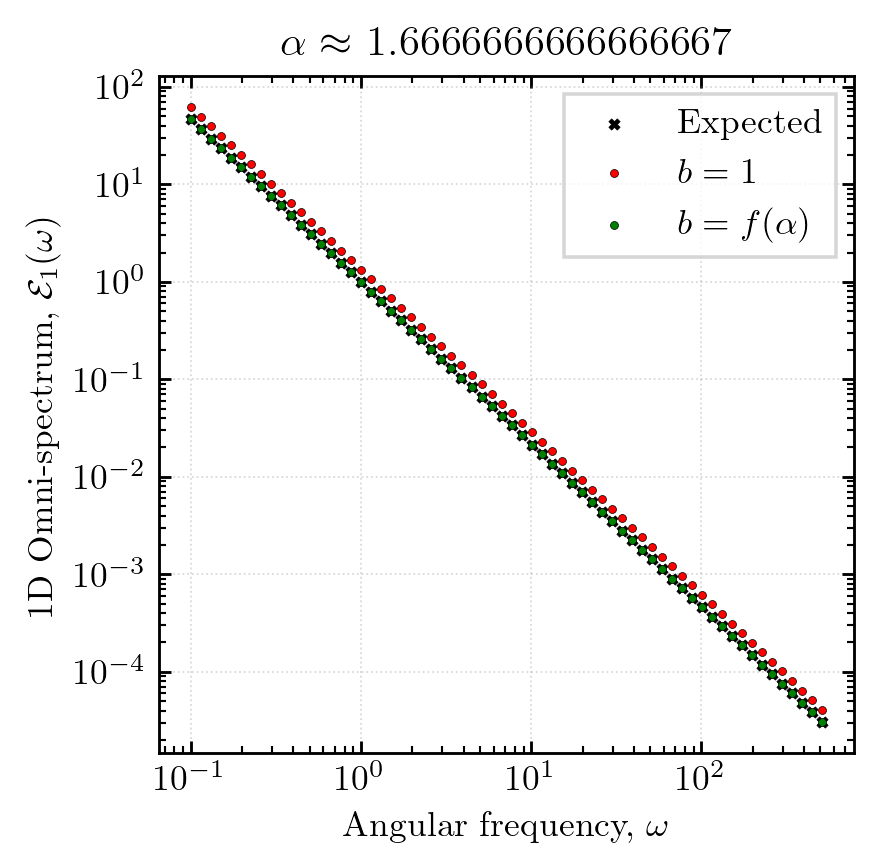

In [19]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

_k = np.exp(np.linspace(np.log(0.1), np.log(512), 64))
_nu = 5./3.

for __k in _k:
    val = E.subs({k: __k, nu: _nu, a: 1.}).evalf()
    ax.scatter(__k, val, marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black')

    val1 = valid.subs({k: __k, nu: _nu, b: 1., a: 1.}).evalf()
    ax.scatter(__k, val1, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

    val2 = valid.subs({k: __k, nu: _nu, b: p.subs({nu: _nu}), a: 1.}).evalf()
    ax.scatter(__k, val2, marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')

ax.loglog()

ax.scatter([], [], marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black', label=r'Expected')
ax.scatter([], [], marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b=1$')
ax.scatter([], [], marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b = f(\alpha)$')

ax.legend(frameon=True, fancybox=False)

ax.set_title(r'$\alpha \approx$ %s' % (_nu))

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'1D Omni-spectrum, $\mathcal{E}_1(\omega)$')
ax.set_xlabel(r'Angular frequency, $\omega$')

#ax.set_ylim((1e-6, 1e1))

fig.savefig('plots/equiv_sf_pure_pwrl_ex.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/equiv_sf_pure_pwrl_ex.png', transparent=True, bbox_inches='tight', pad_inches=0)


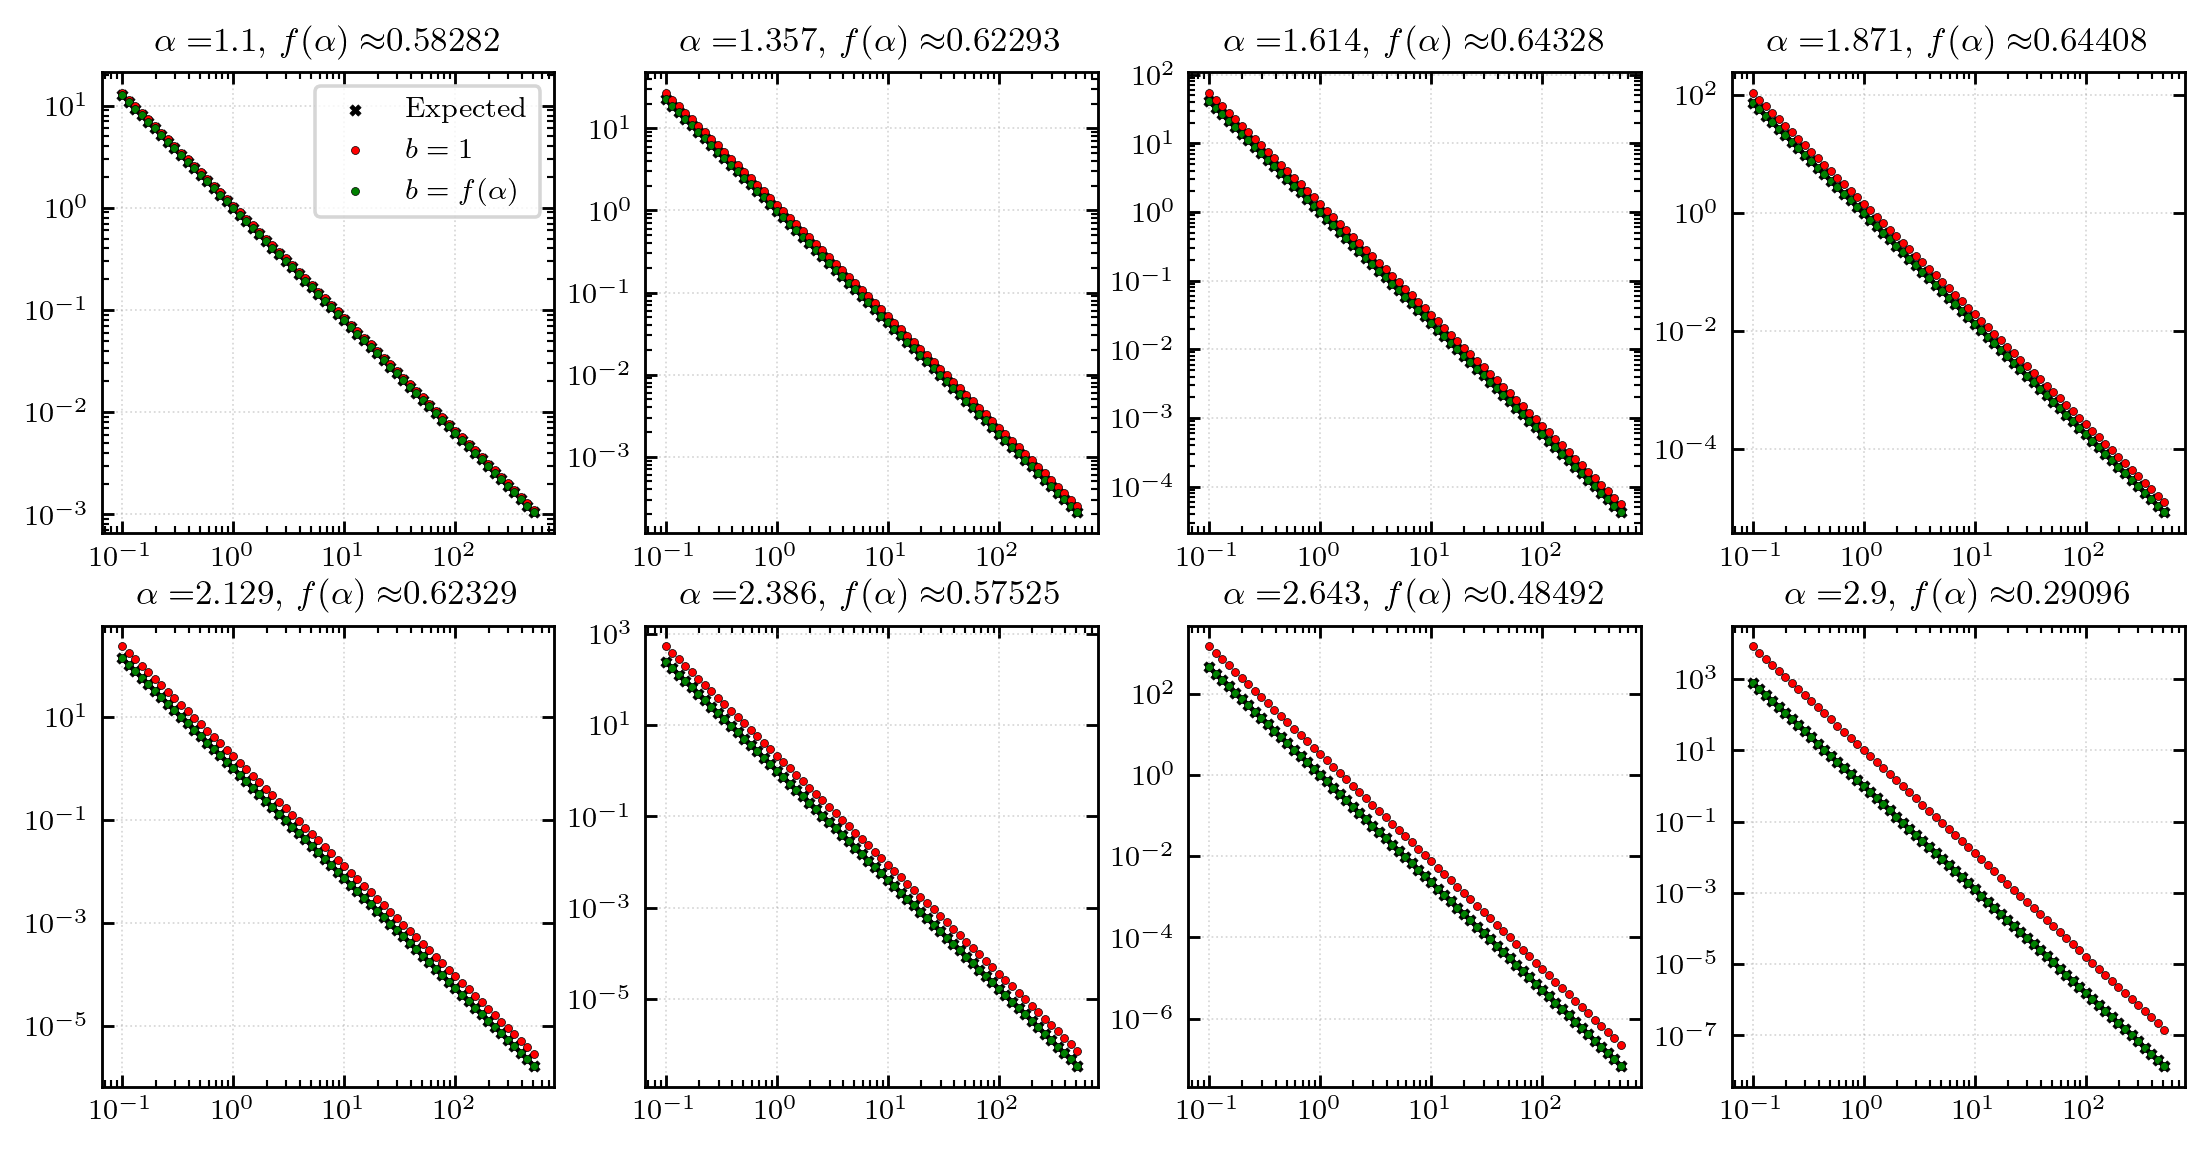

In [45]:

fig, ax = plt.subplots(2, 4, figsize=(3.5*3, 3.5*1.5), dpi=256)

alphas = np.linspace(1.1, 2.9, 8)

_k = np.exp(np.linspace(np.log(0.1), np.log(512), 64))

i = 0
for j in range(2):
    for m in range(4):
        _nu = alphas[i]

        for __k in _k:
            val = E.subs({k: __k, nu: _nu, a: 1.}).evalf()
            ax[j][m].scatter(__k, val, marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black')

            val1 = valid.subs({k: __k, nu: _nu, b: 1., a: 1.}).evalf()
            ax[j][m].scatter(__k, val1, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

            val2 = valid.subs({k: __k, nu: _nu, b: p.subs({nu: _nu}), a: 1.}).evalf()
            ax[j][m].scatter(__k, val2, marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')
        ax[j][m].set_title(r'$\alpha=$%s, $f(\alpha)\approx$%s' % (_nu.round(decimals=3), np.float64(p.subs({nu: _nu}).evalf()).round(decimals=5)))

        i = i + 1

for _axx in ax:
    for axx in _axx:
        axx.set_xscale('log')
        axx.set_yscale('log')
        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')
        axx.tick_params(axis='y', direction='in')
        axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        axx.tick_params(axis='x', direction='in', which='minor')
        axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0][0].scatter([], [], marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black', label=r'Expected')
ax[0][0].scatter([], [], marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b=1$')
ax[0][0].scatter([], [], marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b = f(\alpha)$')
ax[0][0].legend()

fig.savefig('plots/equiv_sf_pure_pwrl.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/equiv_sf_pure_pwrl.png', transparent=True, bbox_inches='tight', pad_inches=0)


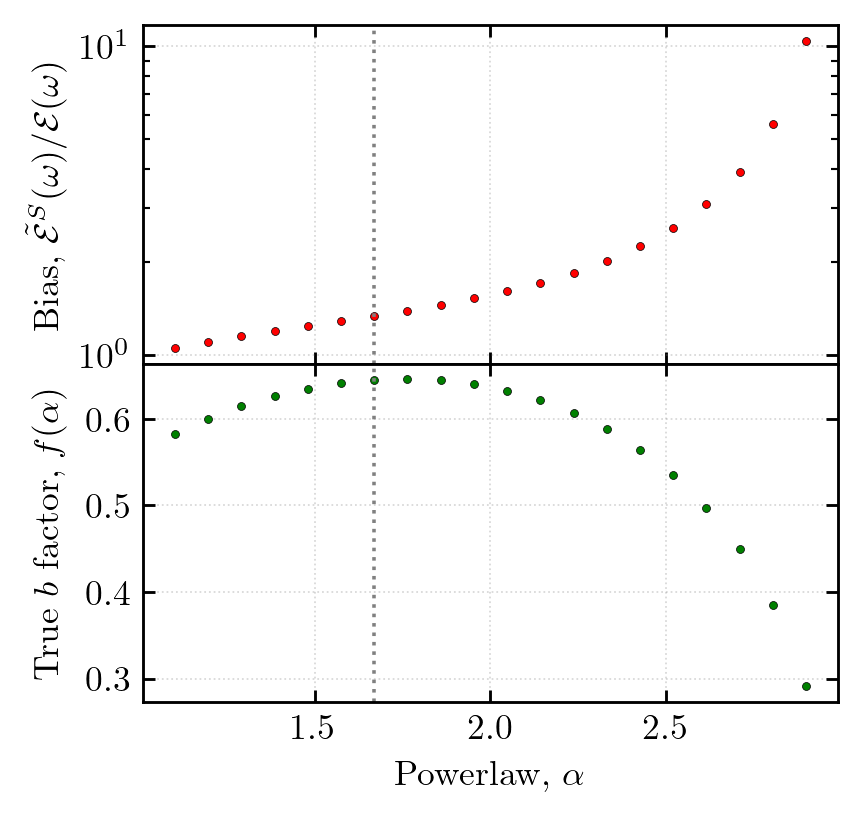

In [33]:

fig, ax = plt.subplots(2, 1, figsize=(3.5, 3.5), dpi=256, sharex=True)

alphas = np.linspace(1.1, 2.9, 20)

for _nu in alphas:
    val1 = bias.subs({nu: _nu}).evalf()
    ax[0].scatter(_nu, val1, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

    val2 = p.subs({nu: _nu}).evalf()
    ax[1].scatter(_nu, val2, marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')

ax[0].set_yscale('log')

ax[0].set_ylabel(r'Bias, $\tilde{\mathcal{E}}^S(\omega) / \mathcal{E}(\omega)$')
ax[1].set_ylabel(r'True $b$ factor, $f(\alpha)$')
ax[1].set_xlabel(r'Powerlaw, $\alpha$')

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    axx.axvline(5./3., color='gray', linewidth=1., linestyle=':')

fig.subplots_adjust(hspace=0.)
fig.align_ylabels()

# fig.savefig('plots/equiv_sf_pure_pwrl.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
# fig.savefig('plots/equiv_sf_pure_pwrl.png', transparent=True, bbox_inches='tight', pad_inches=0)
